# Lab 1: Базові алгоритми класифікації у Scikit-learn

**Датасет:** Cybersecurity Risk and Action Scenarios - https://www.kaggle.com/datasets/ziya07/cybersecurity-threat-detection 

**Мета роботи:** Ознайомитися з базовим workflow задачі класифікації: від вибору та аналізу даних до навчання, налаштування, порівняння та оцінювання моделей машинного навчання з використанням бібліотеки Scikit-learn.

**Задача:** На основі паттернів подій у системах та дій, вчинених для реагування на них, визначити чи дійсно виникла загроза, чи загрози не було

**Автор:** ФБ-62мп Тарасенко Ангеліна


## 0. Завантаження бібліотек

У роботі використовуються бібліотеки `NumPy` і `Pandas` для роботи з даними, `Matplotlib` і `Seaborn` для візуалізації, а також `Scikit-learn` для підготовки даних, відбору ознак, побудови моделей класифікації (KNN, Decision Tree, SVM, Random Forest, AdaBoost), підбору параметрів та оцінювання якості моделей за різними метриками.

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Конфігурація
Спершу робимо необхідні конфігурації для подальшої роботи. Задаємо датасет `DATA_PATH`, таргетовану змінну `TARGET`, яку моделі будуть вгадувати, задаємо гіперпараметри `TUNE_OTHERS` для пошуку найкращих налаштувань методів машинного навчання, `CSV_KWARGS` для зберігання параметрів датасету

In [9]:
DATA_PATH = "telesurgery_cybersecurity_dataset.csv"
TARGET = "Threat Detected"
TUNE_OTHERS = True
CSV_KWARGS = {}

## 2. Завантаження та первинний аналіз даних

Спершу завантажуємо датасет із `DATA_PATH` і отримуємо базову інформацію про нього, як от розмір датасета, назви колонок, перші 5 рядків

In [10]:
df = pd.read_csv(DATA_PATH, **CSV_KWARGS)
print("Розмір датасета (рядки, колонки):", df.shape)
print("\nНазви колонок:")
print(df.columns.tolist())
df.head()

Розмір датасета (рядки, колонки): (1000, 18)

Назви колонок:
['Robot Gesture ID', 'Gesture Type', 'Gesture Coordinates (x, y, z)', 'Timestamp', 'Gesture Duration (sec)', 'Robot Status', 'Message ID', 'Sender', 'Receiver', 'Encryption Algorithm Used', 'Encryption Status', 'Network Latency (ms)', 'Data Transfer Rate (Mbps)', 'Threat Type', 'Threat Severity', 'Response Time (sec)', 'Response Action Taken', 'Threat Detected']


,Robot Gesture ID,Gesture Type,"Gesture Coordinates (x, y, z)",Timestamp,Gesture Duration (sec),Robot Status,Message ID,Sender,Receiver,Encryption Algorithm Used,Encryption Status,Network Latency (ms),Data Transfer Rate (Mbps),Threat Type,Threat Severity,Response Time (sec),Response Action Taken,Threat Detected
0,10,Incision,"(1.48, 1.4, 0.02)",2025-02-14 16:32:27,4.37,Idle,22614,Operator,Robot,Two Fish,Encrypted,11,97,Man-in-the-Middle Attack,Low,4.63,Reset Encryption,1
1,8,Diagnosis,"(1.62, 1.81, 0.68)",2025-02-14 16:32:27,3.08,Idle,61556,Operator,Robot,Two Fish,Encrypted,9,88,DoS Attack,Low,3.94,Reset Encryption,1
2,9,Incision,"(0.67, 1.53, 0.06)",2025-02-14 16:32:27,1.11,Active,27848,Operator,Robot,Two Fish,Encrypted,7,26,No Threat,Low,0.00,NaN,0
3,1,Incision,"(1.63, 1.74, 1.92)",2025-02-14 16:32:27,2.72,Idle,60592,Operator,Robot,Two Fish,Encrypted,13,56,Data Breach,High,4.58,Reconnect Connection,1
4,4,Suturing,"(0.53, 0.87, 1.17)",2025-02-14 16:32:27,1.20,Idle,46712,Robot,Operator,Two Fish,Failed,5,41,Man-in-the-Middle Attack,Low,2.46,Isolate Data,1


Після цього розділяємо датасет на дві вибірки, де `X_raw` буде використана для навчання моделей, а `y_raw` буде зберігати правильні відповіді для подальшого порівняння результатів.

Далі отримуємо кількість ознак, кількість типів даних по колонках, тип даних для кожної окремої колонки.

Після цього ми визначаємо розподіл об'єктів за класами шляхом підрахунку кількості об'єктів у кожному класі та знаходженням їхнього відсоткового співвідношення

Цільова змінна (target): Threat Detected
Кількість ознак (features): 17

Типи даних:
str        11
int64       5
float64     2
Name: count, dtype: int64


,dtype
Robot Gesture ID,int64
Gesture Type,str
"Gesture Coordinates (x, y, z)",str
Timestamp,str
Gesture Duration (sec),float64
Robot Status,str
Message ID,int64
Sender,str
Receiver,str
Encryption Algorithm Used,str



Розподіл об'єктів за класами:


,count,"share, %"
Threat Detected,,
1,717,71.7
0,283,28.3


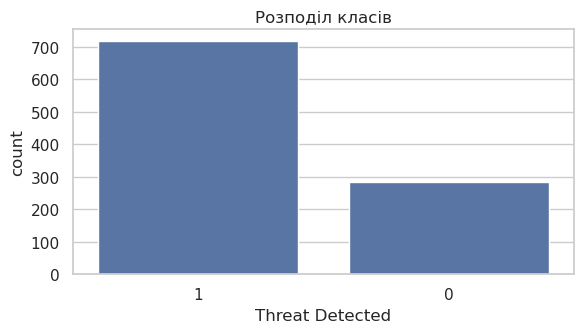

In [11]:
X_raw = df.drop(columns=[TARGET])
y_raw = df[TARGET]

print("Цільова змінна (target):", TARGET)
print("Кількість ознак (features):", X_raw.shape[1])
print("\nТипи даних:")
print(df.dtypes.value_counts())
display(df.dtypes.to_frame("dtype").T if df.shape[1] <= 15 else df.dtypes.to_frame("dtype"))

print("\nРозподіл об'єктів за класами:")
counts = y_raw.value_counts()
display(pd.DataFrame({"count": counts, "share, %": (counts / len(y_raw) * 100).round(2)}))

plt.figure(figsize=(6, 3.5))
sns.countplot(x=y_raw, order=counts.index)
plt.title("Розподіл класів")
plt.tight_layout()
plt.show()

У наведеному датасеті 1 означає, що було виявлено загрозу, а 0 - не виявлено.
Як видно із результатів, датасет відчутно нерівномірний, оскільки ознак, що могли б свідчити про незагрозливий паттерн, лише 28%. 

## 3. Попередня обробка даних

Для подальшої обробки нам необхідно підготувати самі дані для навчання моделей. Для цього спершу ми знайдемо всі колонки, де є порожні рядки. Проходимося по кожному рядку та шукаємо пропуски, а потім рахуємо їх.

Далі необхідно вже видалити порожні рядки та дублікати. Видаляємо саме рядки, де взагалі не вказано цільової змінної, бо вони непридатні для навчання.
У кінці отримуємо підсумок скільки рядків було видалено.

Після цього вже оновлений `X_raw`, значення якого були очищені, ми завантажуємо у `X`.

Далі для оптимізації ресурсів та часу на навчання ми прибираємо колонки, які не є корисними для навчання моделі, наприклад, ті, де майже кожен рядок колонки має унікальне значення (`id_like`) і відсутня кореляція із цільовою змінною, або рядки навпаки всі однакові (`const`).

Далі ми заповнюємо пропуски у інших колонках. Ділимо колонки на числові `num_cols` та нечислові `cat_cols`. Для кожного пропущеного значення у числових колонках ми шукаємо медіану із вже існуючих даних і записуємо їх. Для нечислових колонок ми шукаємо моду, тобто текстове значення, яке зустрічається найчастіше, і записуємо замість пропуску.

Після цього ми перетворюємо всі текстові значення на числові представлення. Через особливості алгоритмів машинного навчання вони не сприймають текст. Для цього ми кладемо всі текстові значення у площину 0 та 1. Текст ділиться на окремі колонки, де їм присвоюється власне кодоване значення із нулів та одиниць.

У кінці нам необхідно перетворити уже саму цільову зміну на числове представлення. Для цього датасету блок є опційним, оскільки цільова зміна уже лежить у площині 0 та 1, однак якщо б там були текстові значення, то їхнє перетворення теж було б необхідним. Для цього ми використовуємо `LabelEncounter()`, результати роботи якого зберігаємо вже у `y`.


In [14]:
na = df.isna().sum()
print("Колонки з пропусками:")
print(na[na > 0] if (na > 0).any() else "Пропусків немає")

n0 = len(df)
df = df.dropna(subset=[TARGET])
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nВидалено рядків (немає target / дублікати): {n0 - len(df)}")

X = df.drop(columns=[TARGET]).copy()

id_like = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c]) and X[c].nunique() == len(X)]
const = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
X = X.drop(columns=id_like + const)
print("Видалені ID-подібні колонки:", id_like)
print("Видалені константні колонки:", const)

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
for c in num_cols:
    if X[c].isna().any():
        X[c] = X[c].fillna(X[c].median())
for c in cat_cols:
    if X[c].isna().any():
        X[c] = X[c].fillna(X[c].mode()[0])

print("\nКатегоріальні ознаки:", cat_cols if cat_cols else "немає")
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)

le = LabelEncoder()
y = pd.Series(le.fit_transform(df[TARGET]), name=TARGET)
class_names = [str(c) for c in le.classes_]
print("Кодування класів:", dict(zip(class_names, range(len(class_names)))))
print("Підсумкова форма X:", X.shape, "| пропусків:", int(X.isna().sum().sum()))

Колонки з пропусками:
Response Action Taken    283
dtype: int64

Видалено рядків (немає target / дублікати): 0
Видалені ID-подібні колонки: ['Gesture Coordinates (x, y, z)']
Видалені константні колонки: ['Timestamp', 'Encryption Algorithm Used']

Категоріальні ознаки: ['Gesture Type', 'Robot Status', 'Sender', 'Receiver', 'Encryption Status', 'Threat Type', 'Threat Severity', 'Response Action Taken']
Кодування класів: {'0': 0, '1': 1}
Підсумкова форма X: (1000, 21) | пропусків: 0


Як видно із результатів, не було виявлено взагалі порожніх рядків у цільовій колонці. Проте були виявлені пропущені значення у колонці `Response Action Taken`, яка містила текстові дані. У підсумку було видалено три колонки, що не несли корисної інформації для визначення цільової змінної, а підсумкова вибірка не змінилась у довжині

## 4. Візуалізація та дослідження даних (EDA)
Далі нам необхідно відкинути колонки, які не є достатньо інформативними, аби відділити класи. Це ми робимо через `SelectKBest` та `f_classif`. Чим більше `f_classif` обраного класу, тим більший його зв'язок із цільовою змінною. Ми отримуємо таку оцінку зв'язку для кожної колонки, а потім сортуємо їх за найбільшим значенням оцінки `f_classif`. 

Для створення Heat map вибираємо максимум 12 ознак із усіх. Для інших графіків беремо максимум 6. Для графіків створюємо окремі таблиці із `X`. Робимо копію `X`, а потім створюємо додаткову колонку `__class__` для кращого відображення графіків. 

Створюємо функцію для відображення декількох графіків у одному вікні.

In [15]:
selector = SelectKBest(f_classif, k="all").fit(X, y)
scores = pd.Series(selector.scores_, index=X.columns).fillna(0).sort_values(ascending=False)
print("Топ-10 ознак за F-статистикою:")
display(scores.head(10).round(2).to_frame("F-score"))

TOP_HEAT = min(12, X.shape[1])
TOP_FEAT = min(6, X.shape[1])
heat_features = scores.head(TOP_HEAT).index.tolist()
top_features = scores.head(TOP_FEAT).index.tolist()

eda_df = X.copy()
eda_df["__class__"] = df[TARGET].astype(str).values

def make_grid(n, ncols=3, h=3.6):
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, h * nrows))
    axes = np.array(axes).reshape(-1)
    for ax in axes[n:]:
        ax.axis("off")
    return fig, axes

Топ-10 ознак за F-статистикою:


,F-score
Threat Type_No Threat,inf
Response Time (sec),1985.72
Response Action Taken_Reconnect Connection,524.36
Threat Type_Man-in-the-Middle Attack,145.70
Threat Type_DoS Attack,141.22
Response Action Taken_Reset Encryption,130.00
Network Latency (ms),3.34
Encryption Status_Failed,3.16
Gesture Duration (sec),1.80
Threat Severity_Low,0.81


### Графік Heat map
Задаємо розміри графіка як 9 на 7 на основі X та найважливіших ознак для навчання, а потім рахуємо кореляцію між кожною парою колонок. Далі будується теплова таблиця кореляцій і створюється сам графік

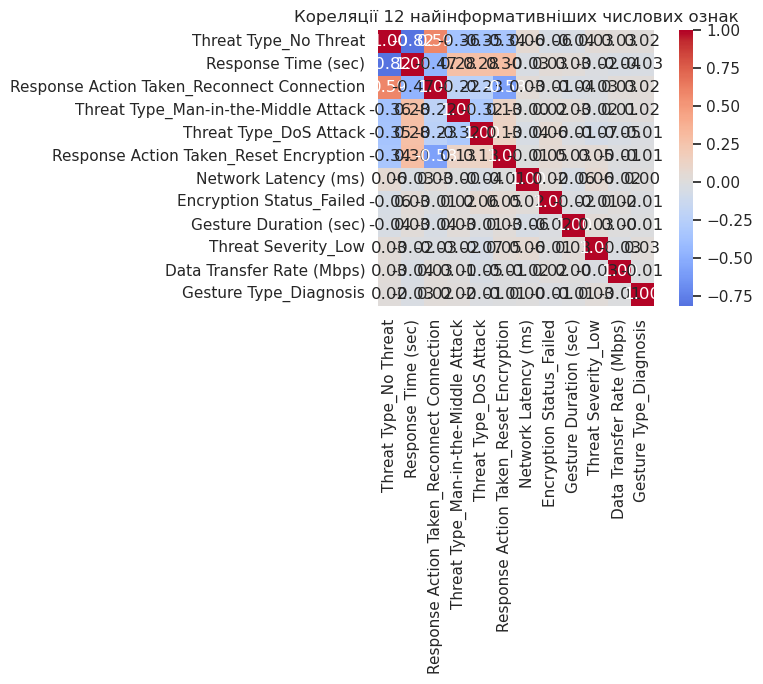

In [16]:
plt.figure(figsize=(9, 7))
sns.heatmap(X[heat_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title(f"Кореляції {TOP_HEAT} найінформативніших числових ознак")
plt.tight_layout()
plt.show()

Як видно із результатів, найбільша кореляція була між `Threat type_No threat` та `Response Action Taken_Reconnect Connection`. Між ними спостерігається навіть логічний зв'язок, оскільки якщо є якісь загрозливі дії - відповідь на них буде, наприклад, перезапуск з'єднання. Якщо дія незагрозлива - ніякої реакції з боку оператора або системи не буде.

### Гістограми
Використовуємо функцію `make_grid`, яку раніше було створено. Після цього для 6 найважливіших ознак ми будуємо по графіку у кожній заданій комірці. Логіка побудови гістограми наступна: значення колонок розділяються на класи, а потім відбувається підрахунок разів, коли вони зустрічалися. Таким чином, ми можемо дізнатися чи відрізняється розподіл ознаки для різних класів і чи може вона допомагати їх розрізняти.

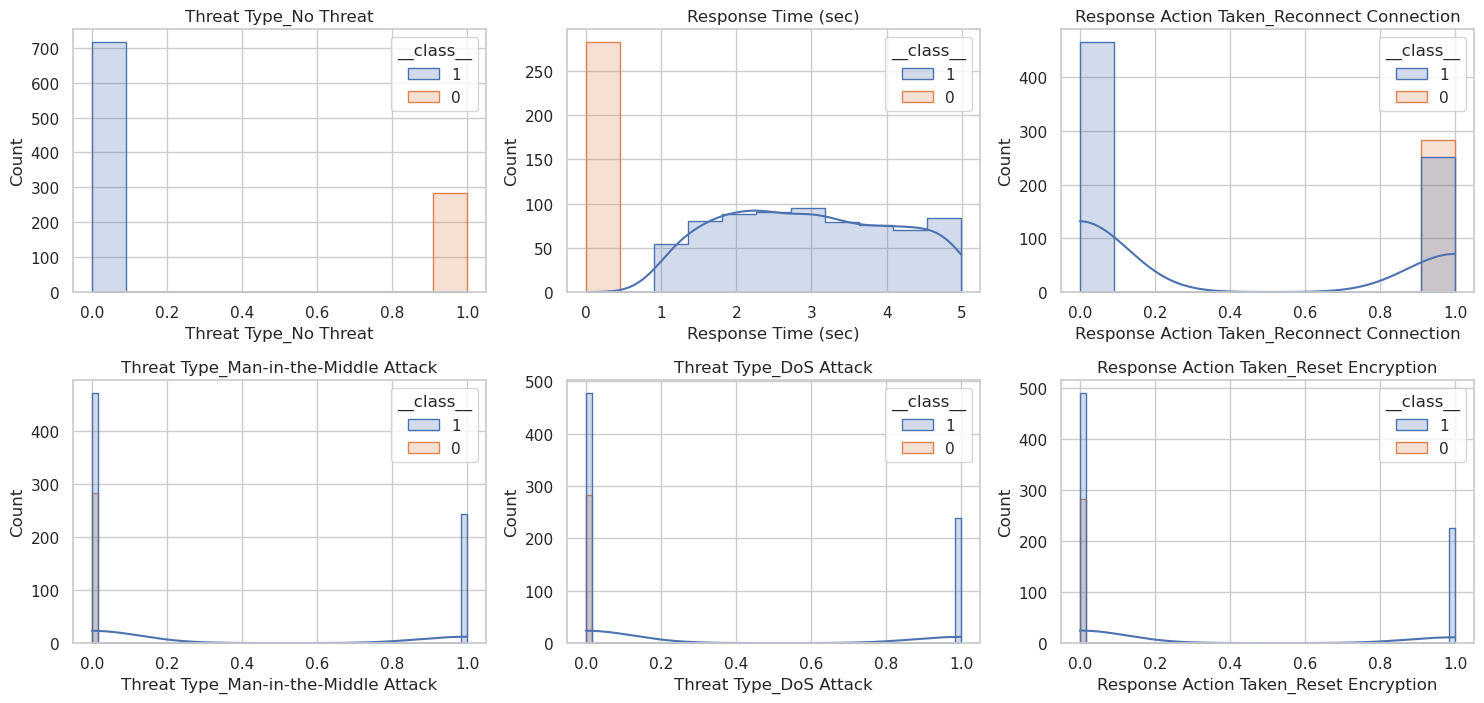

In [17]:
fig, axes = make_grid(len(top_features))
for ax, f in zip(axes, top_features):
    sns.histplot(data=eda_df, x=f, hue="__class__", kde=True, element="step", ax=ax)
    ax.set_title(f)
plt.tight_layout()
plt.show()

Як видно з результатів, `Threat Type_No Threat` і `Response Time` дуже добре розділяють класи, бо значення для 0 і 1 майже не перекриваються. А для `Response Action...`, `Man-in-the-Middle Attack` і `DoS Attack` розподіли частково перекриваються, тому вони теж корисні, але слабше розділяють класи.

### Boxplot
Для кожної важливої ознаки будуємо boxplot окремо для класу 0 і класу 1. Його логіка проста: подивитися, наскільки відрізняються значення ознаки між двома класами.
На boxplot ми дивимося насамперед на положення «ящиків»: якщо вони сильно рознесені й мало перекриваються - ознака добре розділяє класи; якщо майже накладаються один на одного - ознака слабша. Окремі точки далеко від ящика - це викиди.

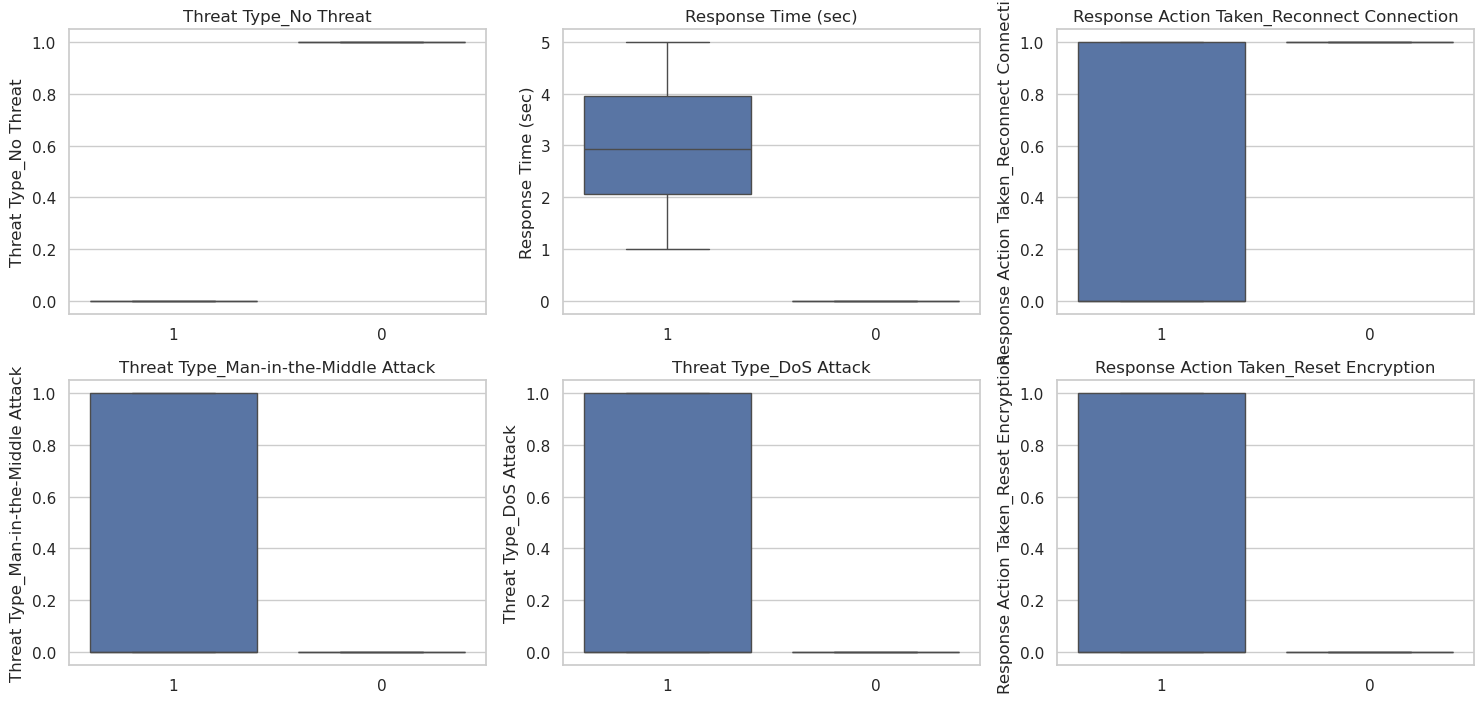

In [18]:
fig, axes = make_grid(len(top_features))
for ax, f in zip(axes, top_features):
    sns.boxplot(data=eda_df, x="__class__", y=f, ax=ax)
    ax.set_xlabel("")
    ax.set_title(f)
plt.tight_layout()
plt.show()

Як видно із результатів, `Threat Type_No Threat` майже ідеально розділяє класи: для класу 0 значення = 1, для класу 1 значення = 0. `Response Time` теж дуже добре розділяє класи: у класу 0 час приблизно рівний 0, а у класу 1 - приблизно 1–5 секунд, медіана близько 3 секунд. `Reconnect Connection` слабша: у класу 0 майже завжди 1, а в класу 1 зустрічаються і 0, і 1. `Man-in-the-Middle Attack`, `DoS Attack` і `Reset Encryption` для класу 0 практично завжди визначають 0, а для класу 1 можуть бути і 0, і 1. Тобто вони допомагають визначати клас 1, але не розділяють класи настільки чітко, як перші дві ознаки.

## 5. Підготовка даних до навчання
Тепер переходимо безпосередньо до створення самих вибірок. Розподіл буде 20% на 80%, де 80% - обсяг навчальної/тренувальної вибірки, а 20% - обсяг тренувальної вибірки.

Далі приводимо всі ознаки до одного масштабу через `StandartScaler`, аби всі значення були приблизно однакового масштабу. Ми перевіряємо розкид даних у `X_train` та середнє значення між ними, на основі яких треба нормувати. Після цього ми застосовуємо нормування вже до обох вибірок.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Частки класів у train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Частки класів у test: ", y_test.value_counts(normalize=True).round(3).to_dict())

Train: (800, 21) | Test: (200, 21)
Частки класів у train: {1: 0.718, 0: 0.282}
Частки класів у test:  {1: 0.715, 0: 0.285}


## 6. Навчання моделей (базові гіперпараметри)
Тепер задаємо 5 моделей, яких ми будемо навчати. Через параметри `True` та `False` ми задаємо для якої моделі будемо використовувати масштабовані дані, а для якої - ні.
Масштабовані дані потрібні для алгоритмів kNN та SVM, оскільки вони працюють через відстані між точками, а отже дуже чутливі до великої різниці у значеннях.
Після цього проводимо навчання кожної вибраної моделі. Кожна модель починає робити свої прогнози. Вимірюємо точність їхнього навчання та тестування.

In [20]:
base_models = {
    "kNN":           (KNeighborsClassifier(), True),
    "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE), False),
    "SVM":           (SVC(random_state=RANDOM_STATE), True),
    "Random Forest": (RandomForestClassifier(random_state=RANDOM_STATE), False),
    "AdaBoost":      (AdaBoostClassifier(random_state=RANDOM_STATE), False),
}

def data_for(scaled):
    return (X_train_s, X_test_s) if scaled else (X_train.values, X_test.values)

base_rows = []
for name, (model, scaled) in base_models.items():
    Xtr, Xte = data_for(scaled)
    model.fit(Xtr, y_train)
    base_rows.append({"Model": name,
                      "Train acc": accuracy_score(y_train, model.predict(Xtr)),
                      "Test acc": accuracy_score(y_test, model.predict(Xte))})
display(pd.DataFrame(base_rows).set_index("Model").round(4))

,Train acc,Test acc
Model,,
kNN,0.9988,0.99
Decision Tree,1.0000,1.00
SVM,1.0000,1.00
Random Forest,1.0000,1.00
AdaBoost,1.0000,1.00


Як видно із результатів, 4 із 5 моделей показали бездоганну точність тестування. Проблеми виникли у моделі kNN

## 7. Підбір гіперпараметрів
Підбираємо найкраще значення k для kNN, тобто скільки найближчих сусідів модель має враховувати. Для цього навчальні дані діляться на 5 частин (`StratifiedKFold`), далі перебираються значення k від 1 до 30, для кожного k дані масштабуються через `StandardScaler`, модель перевіряється 5 разів через крос-валідацію, а середня `accuracy` записується в `cv_scores`; після цього вибирається k з найвищою середньою точністю (`best_k`).

Оптимальне n_neighbors = 23 (CV accuracy = 1.0000)


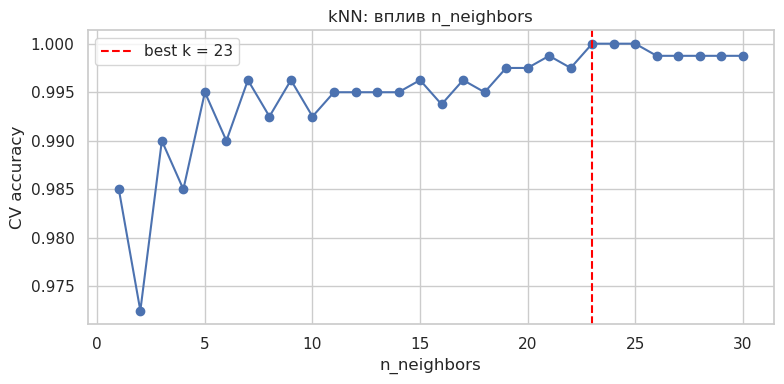

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 6.1 kNN: підбір n_neighbors
k_range = range(1, 31)
cv_scores = []
for k in k_range:
    pipe = Pipeline([("sc", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))])
    cv_scores.append(cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy").mean())

best_k = list(k_range)[int(np.argmax(cv_scores))]
print(f"Оптимальне n_neighbors = {best_k} (CV accuracy = {max(cv_scores):.4f})")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), cv_scores, marker="o")
plt.axvline(best_k, color="red", ls="--", label=f"best k = {best_k}")
plt.xlabel("n_neighbors"); plt.ylabel("CV accuracy"); plt.title("kNN: вплив n_neighbors")
plt.legend(); plt.tight_layout(); plt.show()

Результат показує, що найкраще значення для kNN - k = 23, бо при ньому середня точність крос-валідації досягла 1.0000, тобто 100%. При малих k точність нижча і сильніше коливається, а приблизно після k = 20 вона стабілізується майже на максимумі; 23 обрано як перше значення, де досягнута найвища точність.

Підбираємо найкращі параметри для SVM, а саме `C` і `gamma`, щоб модель працювала максимально точно. Спочатку створюється Pipeline, де дані масштабуються через `StandardScaler`, а потім передаються в SVM з RBF-ядром; далі `GridSearchCV` перебирає всі задані комбінації `C` і `gamma`, для кожної робить крос-валідацію та рахує середню `accuracy`, після чого вибирає найкращу комбінацію. Наприкінці результати всіх комбінацій перетворюються в таблицю і показуються у вигляді heatmap, щоб було видно, при яких `C` і `gamma` точність найвища.

Оптимальні параметри SVM: C = 0.1, gamma = 0.01 (CV accuracy = 1.0000)


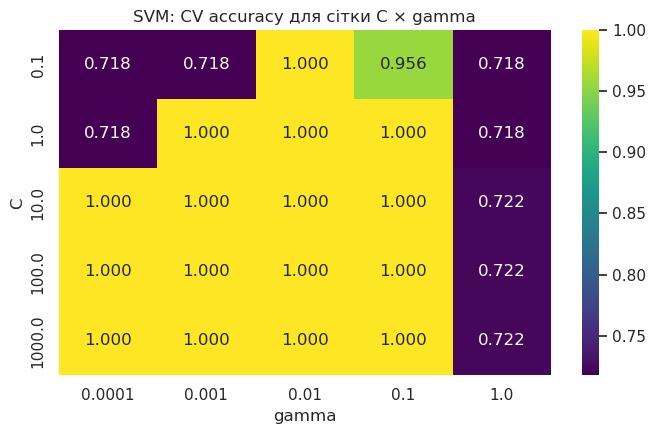

In [22]:
svm_pipe = Pipeline([("sc", StandardScaler()), ("svm", SVC(kernel="rbf", random_state=RANDOM_STATE))])
svm_grid = {
    "svm__C":     [0.1, 1, 10, 100, 1000],
    "svm__gamma": [1e-4, 1e-3, 1e-2, 1e-1, 1],
}
svm_gs = GridSearchCV(svm_pipe, svm_grid, cv=cv, scoring="accuracy", n_jobs=-1)
svm_gs.fit(X_train, y_train)

best_C = svm_gs.best_params_["svm__C"]
best_gamma = svm_gs.best_params_["svm__gamma"]
print(f"Оптимальні параметри SVM: C = {best_C}, gamma = {best_gamma} (CV accuracy = {svm_gs.best_score_:.4f})")

res = pd.DataFrame(svm_gs.cv_results_)
pivot = res.pivot(index="param_svm__C", columns="param_svm__gamma", values="mean_test_score").astype(float)
plt.figure(figsize=(7, 4.5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("gamma"); plt.ylabel("C"); plt.title("SVM: CV accuracy для сітки C × gamma")
plt.tight_layout(); plt.show()

Найкращі параметри SVM вийшли C = 0.1 і gamma = 0.01, при них середня точність крос-валідації дорівнює 1.0000, тобто 100%. На heatmap видно, що багато комбінацій теж дають 100%, особливо при gamma від 0.0001 до 0.1 і більших C, а при gamma = 1 точність різко падає приблизно до 0.72; тобто модель добре працює в широкому діапазоні параметрів, але занадто велике gamma погіршує результат.

Підбираємо найкращі гіперпараметри для Decision Tree, Random Forest і AdaBoost. Спочатку для кожної моделі задаємо набір можливих параметрів: для дерева — глибина і мінімальна кількість об’єктів у листі, для Random Forest — кількість дерев, глибина і мінімум об’єктів у листі, для AdaBoost — кількість моделей і швидкість навчання. Потім `GridSearchCV` перебирає всі комбінації цих параметрів, перевіряє їх через крос-валідацію, вибирає варіант з найвищою `accuracy`, зберігає найкращі параметри в `tuned_params` і виводить їх разом із отриманою точністю

In [24]:
tuned_params = {"Decision Tree": {}, "Random Forest": {}, "AdaBoost": {}}
if TUNE_OTHERS:
    other_grids = {
        "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE),
                          {"max_depth": [3, 5, 7, 10, None], "min_samples_leaf": [1, 3, 5, 10]}),
        "Random Forest": (RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                          {"n_estimators": [100, 300], "max_depth": [None, 10, 20], "min_samples_leaf": [1, 3]}),
        "AdaBoost":      (AdaBoostClassifier(random_state=RANDOM_STATE),
                          {"n_estimators": [50, 100, 300], "learning_rate": [0.01, 0.1, 0.5, 1.0]}),
    }
    for name, (est, grid) in other_grids.items():
        gs = GridSearchCV(est, grid, cv=cv, scoring="accuracy", n_jobs=-1).fit(X_train.values, y_train)
        tuned_params[name] = gs.best_params_
        print(f"{name:14s} -> {gs.best_params_} | CV accuracy = {gs.best_score_:.4f}")

Decision Tree  -> {'max_depth': 3, 'min_samples_leaf': 1} | CV accuracy = 1.0000
Random Forest  -> {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100} | CV accuracy = 1.0000
AdaBoost       -> {'learning_rate': 0.01, 'n_estimators': 50} | CV accuracy = 1.0000


Як видно із результатів, для Decision Tree найкращими параметрами стала максимальна глибина 3 та мінімальна кількість листків 1. При цьому така модель отримала результат з точності як 1.
Для Random Forest найкращі результати показала необмежена глибина, мінімальна кількість листків як 1 та кількість дерев 100. При такій конфігурації модель отримала результат з точності як 1.
AdaBoost показала себе найкраще при 50 деревах та оцінкою навчання як 0.01.

## 8. Порівняння та оцінювання моделей
Фінальні моделі — з підібраними гіперпараметрами, навчені на всьому train і оцінені на test.

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Model,,,,
Decision Tree,1.000,1.0000,1.0000,1.0000
SVM,1.000,1.0000,1.0000,1.0000
Random Forest,1.000,1.0000,1.0000,1.0000
AdaBoost,1.000,1.0000,1.0000,1.0000
kNN,0.995,0.9914,0.9965,0.9939


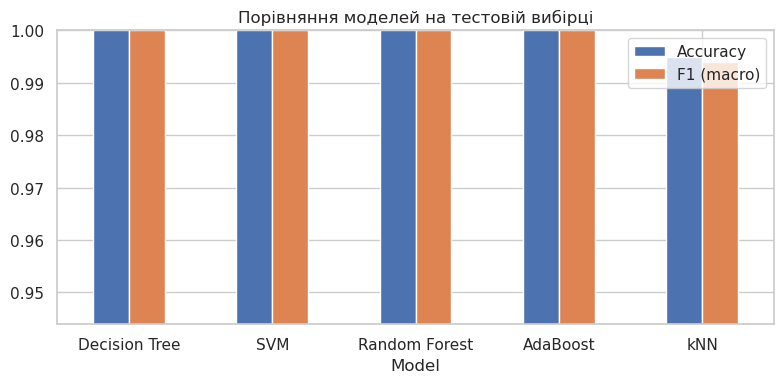

Найкраща модель за F1 (macro): Decision Tree


In [25]:
final_models = {
    "kNN":           (KNeighborsClassifier(n_neighbors=best_k), True),
    "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE, **tuned_params["Decision Tree"]), False),
    "SVM":           (SVC(kernel="rbf", C=best_C, gamma=best_gamma, random_state=RANDOM_STATE), True),
    "Random Forest": (RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **tuned_params["Random Forest"]), False),
    "AdaBoost":      (AdaBoostClassifier(random_state=RANDOM_STATE, **tuned_params["AdaBoost"]), False),
}

predictions, rows = {}, []
for name, (model, scaled) in final_models.items():
    Xtr, Xte = data_for(scaled)
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    predictions[name] = pred
    rows.append({
        "Model": name,
        "Accuracy":        accuracy_score(y_test, pred),
        "Precision (macro)": precision_score(y_test, pred, average="macro", zero_division=0),
        "Recall (macro)":    recall_score(y_test, pred, average="macro", zero_division=0),
        "F1 (macro)":        f1_score(y_test, pred, average="macro", zero_division=0),
    })

results = pd.DataFrame(rows).set_index("Model").sort_values("F1 (macro)", ascending=False)
display(results.round(4))

results[["Accuracy", "F1 (macro)"]].plot(kind="bar", figsize=(8, 4), rot=0)
lo = max(0, results[["Accuracy", "F1 (macro)"]].values.min() - 0.05)
plt.ylim(lo, 1.0); plt.title("Порівняння моделей на тестовій вибірці")
plt.tight_layout(); plt.show()

best_name = results.index[0]
print("Найкраща модель за F1 (macro):", best_name)

За результатами Decision Tree, SVM, Random Forest і AdaBoost показали ідеальну якість на тестовій вибірці: Accuracy, Precision, Recall і F1 у них дорівнюють 1.0000, тобто всі тестові об’єкти класифіковано правильно. kNN спрацював трохи гірше: Accuracy = 0.995, F1 = 0.9939, але це теж дуже високий результат. Оскільки таблиця відсортована за F1, першою стоїть Decision Tree, тому код формально називає її найкращою, хоча фактично чотири моделі мають однаково максимальний результат.

In [26]:
for name, pred in predictions.items():
    print("=" * 60)
    print(name)
    print(classification_report(y_test, pred, target_names=class_names, digits=3, zero_division=0))

kNN
              precision    recall  f1-score   support

           0      0.983     1.000     0.991        57
           1      1.000     0.993     0.996       143

    accuracy                          0.995       200
   macro avg      0.991     0.997     0.994       200
weighted avg      0.995     0.995     0.995       200

Decision Tree
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        57
           1      1.000     1.000     1.000       143

    accuracy                          1.000       200
   macro avg      1.000     1.000     1.000       200
weighted avg      1.000     1.000     1.000       200

SVM
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        57
           1      1.000     1.000     1.000       143

    accuracy                          1.000       200
   macro avg      1.000     1.000     1.000       200
weighted avg      1.000     1.000     1.000       20

Результати показують, що Decision Tree, SVM, Random Forest і AdaBoost класифікували всі 200 тестових об’єктів правильно, тому для них precision, recall, F1-score і accuracy дорівнюють 1.000. kNN допустив лише одну помилку: усі 57 об’єктів класу 0 визначені правильно, а з 143 об’єктів класу 1 один був помилково віднесений до класу 0, тому його загальна точність становить 99,5%. Також видно, що класи трохи незбалансовані — 57 об’єктів класу 0 і 143 класу 1, але моделі все одно показали дуже високі результати.

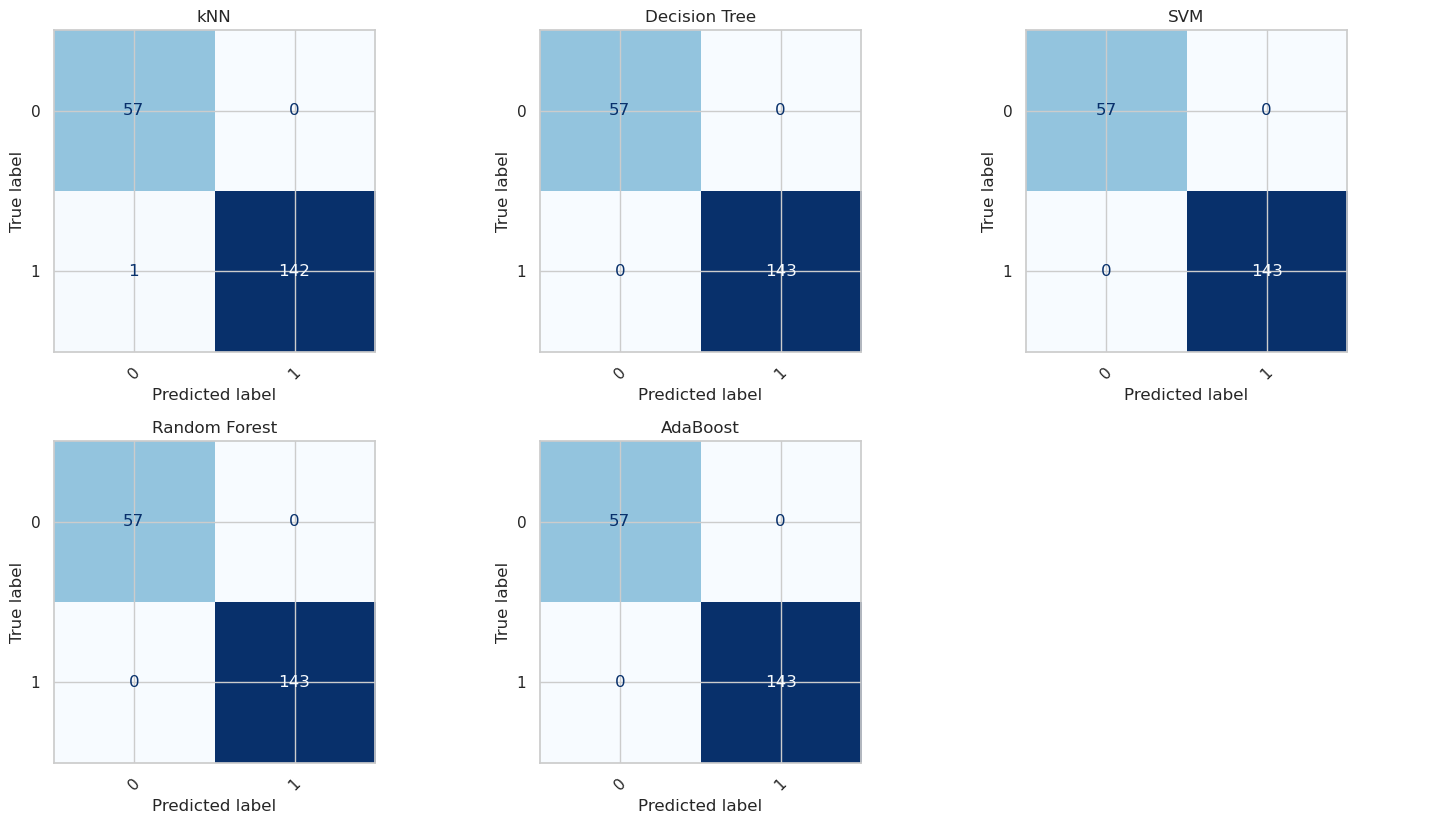

In [27]:
fig, axes = make_grid(len(predictions), ncols=3, h=4.2)
for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Матриці помилок показують, скільки об’єктів кожного класу модель визначила правильно і неправильно. У Decision Tree, SVM, Random Forest та AdaBoost усі 57 об’єктів класу 0 і 143 об’єкти класу 1 визначені правильно, помилок немає. У kNN правильно визначено всі 57 об’єктів класу 0 і 142 із 143 об’єктів класу 1, а один об’єкт класу 1 помилково віднесено до класу 0. Тобто матриці підтверджують попередній результат: чотири моделі мають 100% точність, а kNN — 99,5%.

,CV F1 mean,CV F1 std
Model,,
kNN,1.0,0.0
Decision Tree,1.0,0.0
SVM,1.0,0.0
Random Forest,1.0,0.0
AdaBoost,1.0,0.0


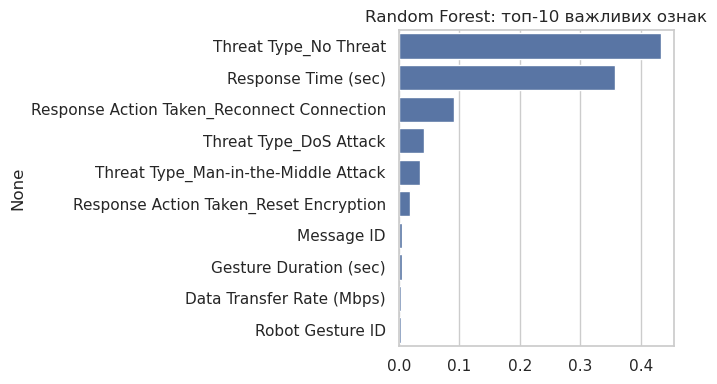

In [28]:
cv_rows = []
for name, (model, scaled) in final_models.items():
    est = Pipeline([("sc", StandardScaler()), ("m", model)]) if scaled else model
    s = cross_val_score(est, X.values, y, cv=cv, scoring="f1_macro")
    cv_rows.append({"Model": name, "CV F1 mean": s.mean(), "CV F1 std": s.std()})
display(pd.DataFrame(cv_rows).set_index("Model").round(4))

rf = final_models["Random Forest"][0]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 4))
sns.barplot(x=imp.values, y=imp.index)
plt.title("Random Forest: топ-10 важливих ознак")
plt.tight_layout(); plt.show()

По-перше, всі 5 моделей мають CV F1 mean = 1.0 і CV F1 std = 0.0, тобто під час крос-валідації кожна модель стабільно показувала ідеальний F1 без коливань між фолдами. По-друге, графік Random Forest показує, які ознаки найбільше впливали на рішення: найважливішою є Threat Type_No Threat, далі Response Time (sec), потім Response Action Taken_Reconnect Connection, а решта ознак мають значно менший внесок; тобто модель в основному спирається саме на ці кілька ознак.

## Висновок
- **Найкраща модель**: однозначного єдиного переможця немає — Decision Tree, SVM, Random Forest і AdaBoost показали однаково найкращий результат: Accuracy = 1.000 і F1 = 1.000. Формально код вибрав Decision Tree, оскільки вона першою стоїть у відсортованій таблиці. Усі чотири моделі правильно класифікували всі 200 тестових об’єктів і показали стабільний результат при крос-валідації (CV F1 mean = 1.0, std = 0.0). Random Forest додатково показав, що найбільший вплив мають ознаки Threat Type_No Threat і Response Time (sec).
- **Слабші моделі**: найслабшою в цьому експерименті виявилась kNN, хоча її результат теж дуже високий — Accuracy = 0.995, F1 = 0.9939. Вона допустила лише одну помилку.
- **Помилки моделей**: Decision Tree, SVM, Random Forest і AdaBoost помилок не допустили. kNN правильно визначила всі 57 об’єктів класу 0 і 142 із 143 об’єктів класу 1, один об’єкт класу 1 помилково віднесла до класу 0. Тому для цієї задачі важливо враховувати не тільки accuracy, а й recall, щоб не пропускати об’єкти класу 1.
- **Роль гіперпараметрів**: для kNN було підібрано оптимальне k = 23, при якому CV accuracy досягла 1.0000. Для SVM оптимальними стали C = 0.1 і gamma = 0.01, також із CV accuracy 1.0000. Для Decision Tree, Random Forest і AdaBoost GridSearchCV також підібрав найкращі комбінації параметрів. У підсумку після налаштування чотири з п’яти моделей досягли ідеальної якості на тестовій вибірці.